# XGBoost

https://xgboost.readthedocs.io

XGBoost(Extreme Gradient Boosting)는 Gradient Boosting 계열의 대표적인 실무형 라이브러리이다.

앞에서 본 Gradient Boosting / HistGradientBoosting과 마찬가지로,
이전 단계 모델의 오차를 다음 트리가 순차적으로 보완해 가는 boosting의 기본 철학은 그대로 유지한다.

다만 XGBoost는 단순히 성능이 좋은 부스팅 모델에 그치지 않고,
실제 실무에서 모델을 더 안정적으로 학습·관리할 수 있도록 여러 기능을 강화한 라이브러리라는 점이 중요하다.

핵심 특징
- Gradient Boosting 기반: 이전 트리의 오차를 줄이는 방향으로 새 트리를 순차적으로 추가한다.
- 정규화(L1, L2): 모델이 너무 복잡해지는 것을 막아 과적합을 줄이는 데 도움을 준다.
- Early Stopping: 검증 성능이 더 좋아지지 않으면 학습을 조기에 멈출 수 있다.
- 학습 과정 추적: eval_set, eval_metric 등을 통해 train/validation 성능 변화를 확인할 수 있다.
- 중요도 확인: 어떤 특성이 예측에 크게 기여했는지 해석할 수 있다.

## 환경설정

In [12]:
import xgboost

xgboost.__version__

'3.2.0'

## 분류

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# iris
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# as_frame=True DataFrame/Series 반환
X, y = load_iris(return_X_y=True, as_frame=True)
print(type(X), type(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(X_tr.shape, y_tr.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

<class 'pandas.DataFrame'> <class 'pandas.Series'>
(108, 4) (108,)
(12, 4) (12,)
(30, 4) (30,)


In [27]:
# 모델 학습
from xgboost import XGBClassifier


# XGBClassifier : sklearn 스타일로 사용할 수 있는 XGBoost 분류 모델
xgb_clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=5,
    early_stopping_rounds=10,
    # 다중 분류 평가 지표
    # 정답 클래스 확률만 뽑아서 로그를 씌운 뒤 음수로 바꿔 평균 낸 값
    eval_metrcis='mlogloss'
)

# early_stopping_rounds 설정을 했을 경우 검증용 셋도 설정해야 한다. (eval_set 설정)
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=True)

[0]	validation_0-mlogloss:0.96808	validation_1-mlogloss:0.96210
[1]	validation_0-mlogloss:0.85853	validation_1-mlogloss:0.84769
[2]	validation_0-mlogloss:0.76530	validation_1-mlogloss:0.75044
[3]	validation_0-mlogloss:0.68513	validation_1-mlogloss:0.66742
[4]	validation_0-mlogloss:0.61563	validation_1-mlogloss:0.59501


[5]	validation_0-mlogloss:0.55500	validation_1-mlogloss:0.53191
[6]	validation_0-mlogloss:0.50183	validation_1-mlogloss:0.47661
[7]	validation_0-mlogloss:0.45500	validation_1-mlogloss:0.42795
[8]	validation_0-mlogloss:0.41361	validation_1-mlogloss:0.38496
[9]	validation_0-mlogloss:0.37707	validation_1-mlogloss:0.34689
[10]	validation_0-mlogloss:0.34455	validation_1-mlogloss:0.31305
[11]	validation_0-mlogloss:0.31554	validation_1-mlogloss:0.28292
[12]	validation_0-mlogloss:0.28961	validation_1-mlogloss:0.25603
[13]	validation_0-mlogloss:0.26639	validation_1-mlogloss:0.23199
[14]	validation_0-mlogloss:0.24556	validation_1-mlogloss:0.21047
[15]	validation_0-mlogloss:0.22686	validation_1-mlogloss:0.19113
[16]	validation_0-mlogloss:0.21002	validation_1-mlogloss:0.17380
[17]	validation_0-mlogloss:0.19485	validation_1-mlogloss:0.15820
[18]	validation_0-mlogloss:0.18115	validation_1-mlogloss:0.14415
[19]	validation_0-mlogloss:0.16848	validation_1-mlogloss:0.13152
[20]	validation_0-mlogloss:0.1

c:\Users\test\miniforge3\envs\ai_basic_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [15:12:18] WARNING: D:\bld\xgboost-split_1772124962567\work\src\learner.cc:782: 
Parameters: { "eval_metrcis" } are not used.

  self.starting_round = model.num_boosted_rounds()


[89]	validation_0-mlogloss:0.02622	validation_1-mlogloss:0.00931
[90]	validation_0-mlogloss:0.02607	validation_1-mlogloss:0.00923
[91]	validation_0-mlogloss:0.02594	validation_1-mlogloss:0.00920
[92]	validation_0-mlogloss:0.02582	validation_1-mlogloss:0.00917
[93]	validation_0-mlogloss:0.02570	validation_1-mlogloss:0.00914
[94]	validation_0-mlogloss:0.02560	validation_1-mlogloss:0.00906
[95]	validation_0-mlogloss:0.02548	validation_1-mlogloss:0.00903
[96]	validation_0-mlogloss:0.02533	validation_1-mlogloss:0.00895
[97]	validation_0-mlogloss:0.02522	validation_1-mlogloss:0.00892
[98]	validation_0-mlogloss:0.02512	validation_1-mlogloss:0.00884
[99]	validation_0-mlogloss:0.02501	validation_1-mlogloss:0.00882
[100]	validation_0-mlogloss:0.02491	validation_1-mlogloss:0.00874
[101]	validation_0-mlogloss:0.02478	validation_1-mlogloss:0.00867
[102]	validation_0-mlogloss:0.02466	validation_1-mlogloss:0.00858
[103]	validation_0-mlogloss:0.02453	validation_1-mlogloss:0.00851
[104]	validation_0-ml

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [28]:
from sklearn.metrics import classification_report

print('train accuracy:', xgb_clf.score(X_tr, y_tr))
print('test accuracy:', xgb_clf.score(X_test, y_test))
print(classification_report(y_test, xgb_clf.predict(X_test)))

train accuracy: 1.0


ValueError: Feature shape mismatch, expected: 4, got 8

### plot_importance()
- 학습된 모델이 어떤 특성을 자주/크게 사용했는지 시각화한다.
- 트리 분할에 많이 사용되었거나, 손실 감소에 크게 기여한 특성이 위로 올라온다.
- "이 모델이 무엇을 중요하게 봤는가?"를 빠르게 확인할 때 자주 사용한다.

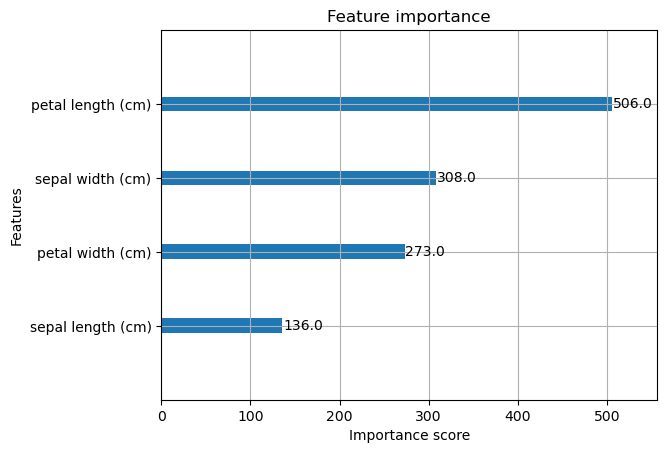

In [ ]:
from xgboost import plot_importance

plot_importance(xgb_clf)
plt.show()

## XGBoost 분류 모델 특성 추가 확인

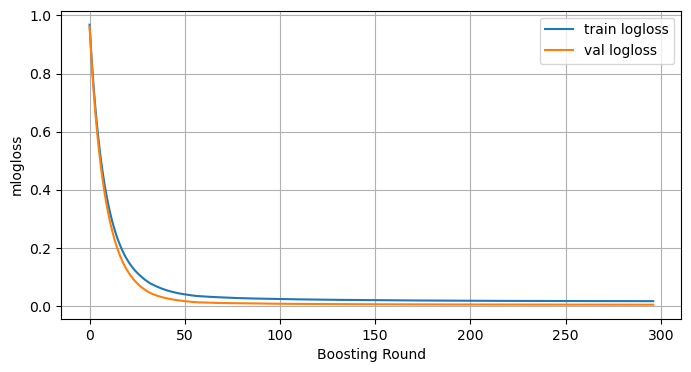

best_iteration: 286
best_score: 0.00529800379202546


In [29]:
# 학습 과정 확인
results = xgb_clf.evals_result()

train_logloss = results['validation_0']['mlogloss']
val_logloss = results['validation_1']['mlogloss']

plt.figure(figsize=(8, 4))
plt.plot(train_logloss, label="train logloss")
plt.plot(val_logloss, label="val logloss")
plt.xlabel("Boosting Round")
plt.ylabel("mlogloss")
plt.legend()
plt.grid(True)
plt.show()

# 반복 횟수, 평가 점수
print('best_iteration:', xgb_clf.best_iteration)
print('best_score:', xgb_clf.best_score)

## 회귀

In [24]:
# 캘리포니아 주택 가격 데이터 로드
df = pd.read_csv('data/california_housing.csv')

# 데이터 구조 확인
print(df.head())
print(df.info())

# 타겟과 피처 분리
X = df.drop('MedHouseVal', axis=1).to_numpy()
y = df['MedHouseVal'].to_numpy()

# 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

In [26]:
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'    # 회귀용 목적 함수
)

xgb_reg.fit(X_train, y_train)

print('train r^2', xgb_reg.score(X_train, y_train))
print('test r^2', xgb_reg.score(X_test, y_test))
print('train RMSE', root_mean_squared_error(y_train,xgb_reg.predict(X_train)))
print('train r^2', root_mean_squared_error(y_test,xgb_reg.predict(X_test)))


train r^2 0.8664308390320528
test r^2 0.814103964336009
train RMSE 0.4225545457676993
train r^2 0.493558339159095
